In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('Bank customer churn.csv')
df


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [ ]:
df = df.drop(['id', 'CustomerId', 'Surname' ], axis=1)
df[['NumOfProducts', 'CreditScore', 'Age', 'HasCrCard', 'IsActiveMember', 'Exited', 'Tenure' ]] = df[['NumOfProducts', 'CreditScore', 'Age', 'HasCrCard', 'IsActiveMember', 'Exited', 'Tenure' ]].astype(int)
# df.isna().value_counts() ստուգում ենք NAN արծեքներ կան թե չէ (չկային)

# սա ավելացրել եմ գրաֆիկներից հետո
df['old customers'] = df['Age']>=45

In [11]:
df['Exited'].value_counts()

Exited
0    11948
1     3052
Name: count, dtype: int64

In [12]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,old customers
0,678,France,Male,29,4,0.00,3,1,0,180626.36,0,False
1,687,France,Female,34,1,0.00,2,0,1,63736.17,0,False
2,682,France,Female,52,6,0.00,3,0,0,179655.87,1,True
3,753,Germany,Male,44,6,83347.25,2,1,0,161407.48,0,False
4,544,Germany,Female,55,0,107747.57,1,1,0,176580.86,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...
14995,585,France,Male,33,3,0.00,1,1,0,54191.38,0,False
14996,678,France,Male,34,6,0.00,2,1,1,53437.10,0,False
14997,678,France,Female,54,4,0.00,1,1,0,147720.29,1,True
14998,705,Spain,Female,40,7,0.00,2,1,0,149550.95,0,False


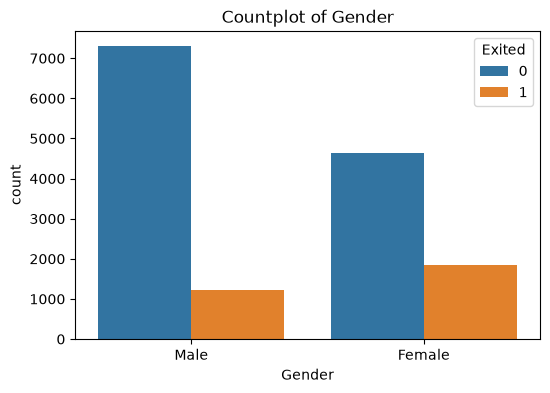

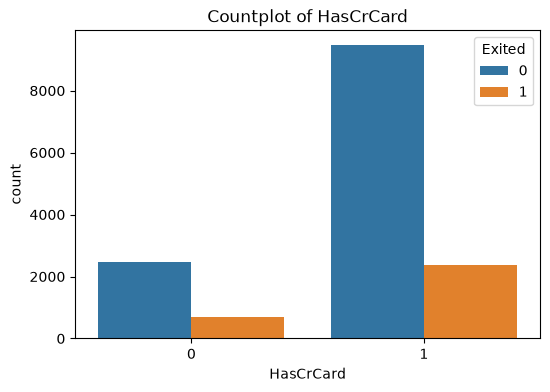

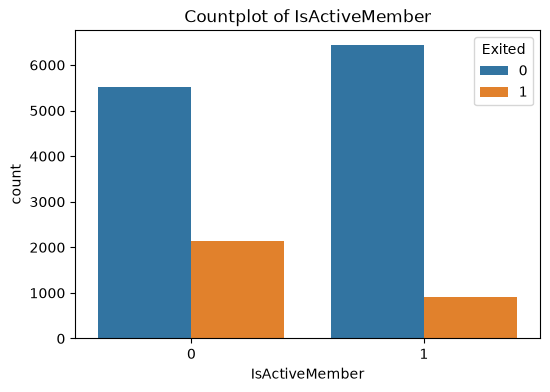

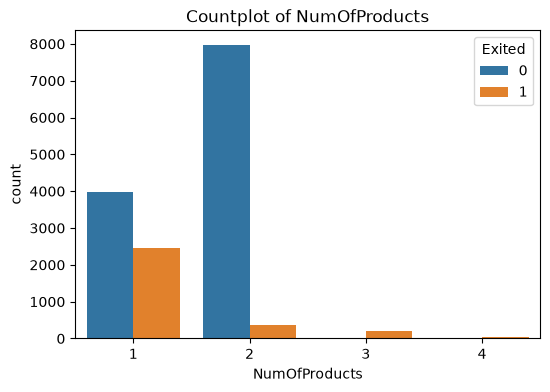

In [14]:
cat_cols = ['Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='Exited')
    plt.title(f'Countplot of {col}')
    plt.show()

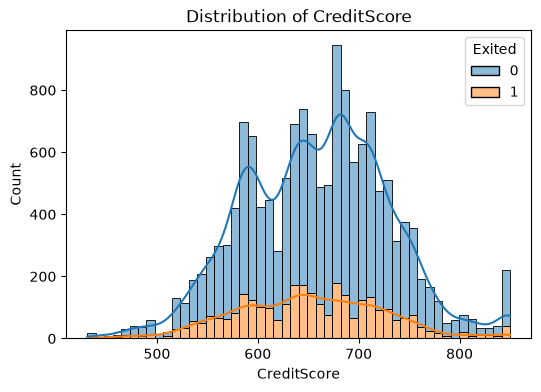

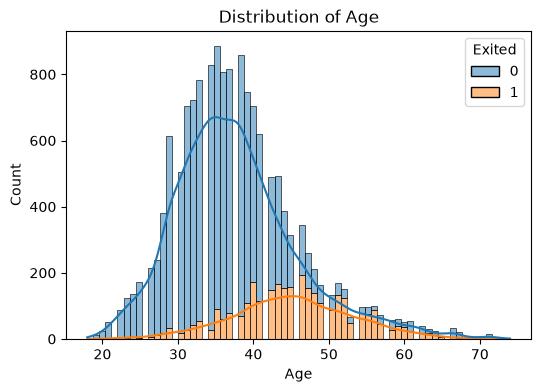

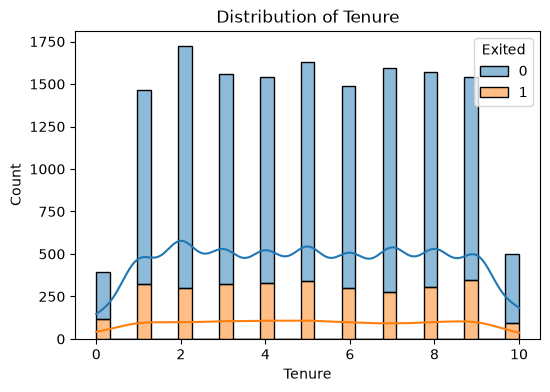

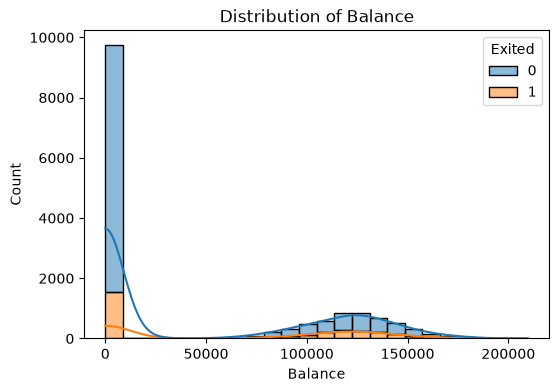

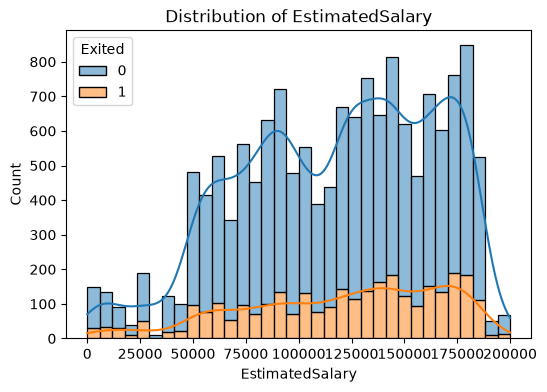

In [15]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='Exited', kde=True, multiple='stack')
    plt.title(f'Distribution of {col}')
    plt.show()

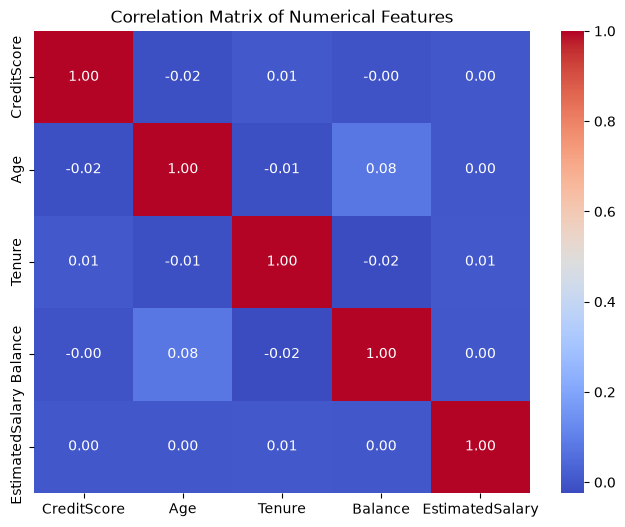

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

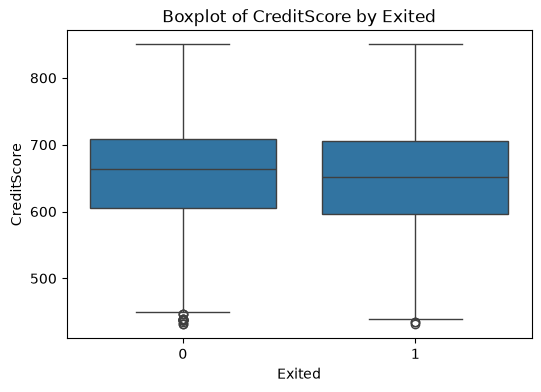

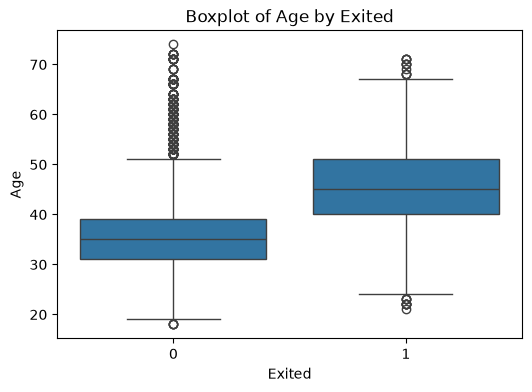

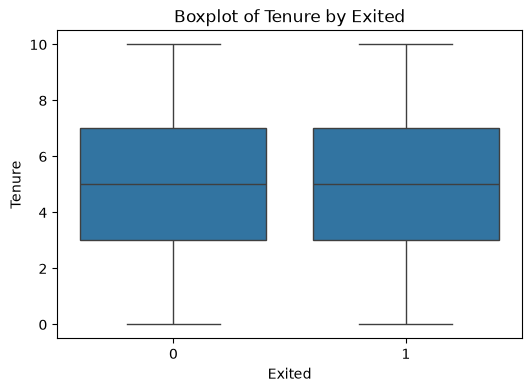

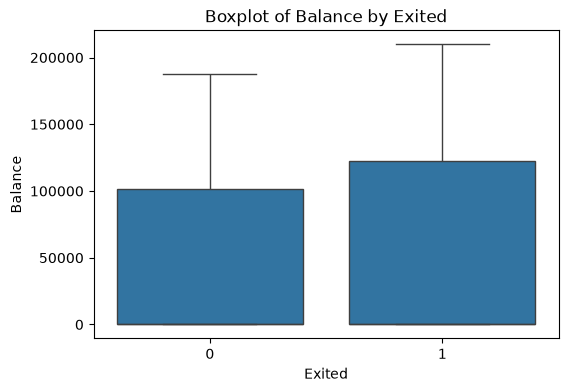

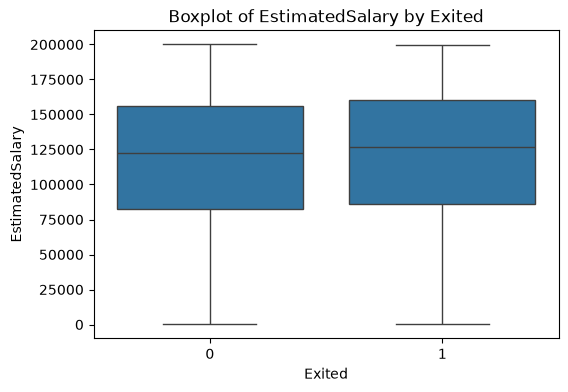

In [17]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='Exited', y=col)
    plt.title(f'Boxplot of {col} by Exited')
    plt.show()